In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow import keras

In [3]:
# Loading the data  --> keras dataset object
df = tf.keras.utils.image_dataset_from_directory(
    directory = "RealWaste",
    label_mode='int',
    image_size=(224, 224),
    batch_size=32,
    color_mode = 'rgb',
    labels='inferred',
)

Found 4752 files belonging to 9 classes.


Visualizing  Waste Images

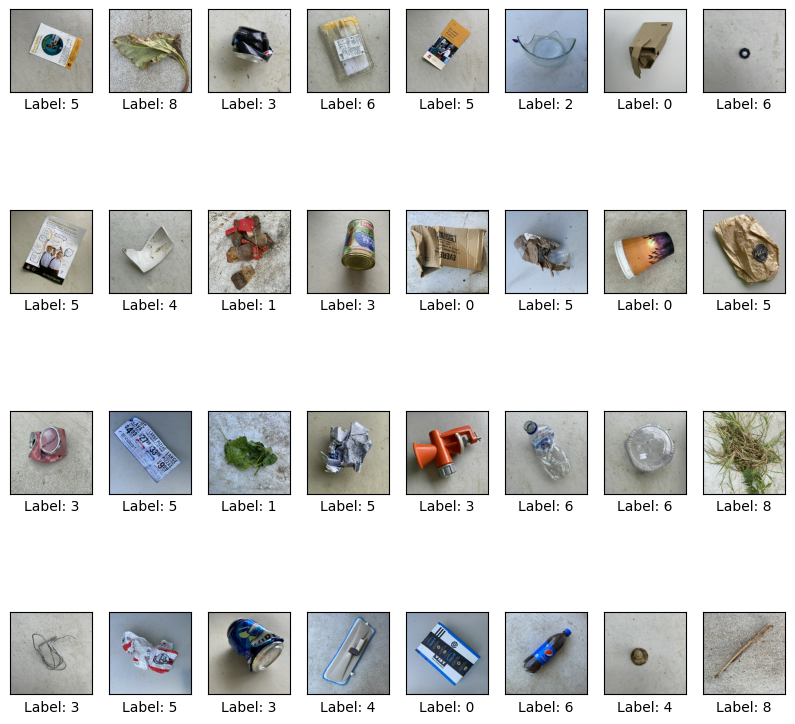

In [35]:
def visualize_images(dfobject):
    plt.figure(figsize=(10,10))
    #we are taking only 1 batch = 32 images
    for images ,labels in dfobject.take(1):
        # We are iterating over all 32 images
        for i in range(32):
            #converting tensorflow object into numpy array
            image=images[i].numpy()
            label = labels[i].numpy()
            plt.subplot(4,8,i+1)
            plt.imshow(image.astype("uint8")) 
            plt.xlabel(f"Label: {label}")
            plt.xticks([])
            plt.yticks([])

visualize_images(df)


Preprocessing The Images

In [36]:
def preprocess(image,label):
    # converting the datatype by cast then Normalizing each pixel value
    image = tf.cast(image,tf.float32)/255
    return image,label

df = df.map(preprocess)